✅ Success: Data streamed. Rows: 20000


/tmp/ipykernel_1411/2171910543.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes': 1, 'No': 0, 'Major': 1, 'Minor': 0})



 FINAL MODEL ACCURACY: 0.9992


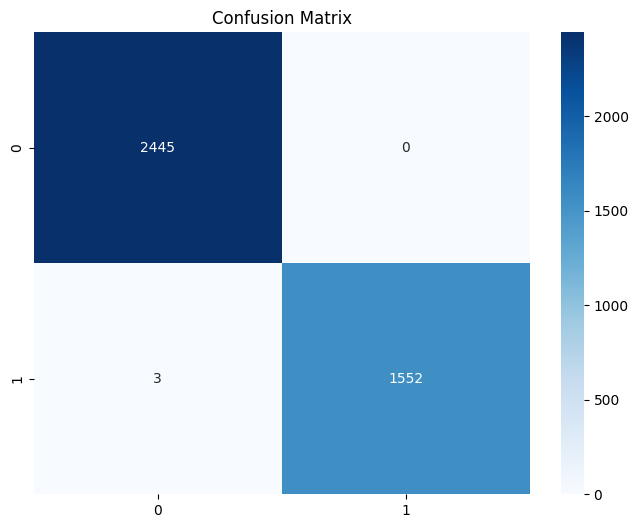

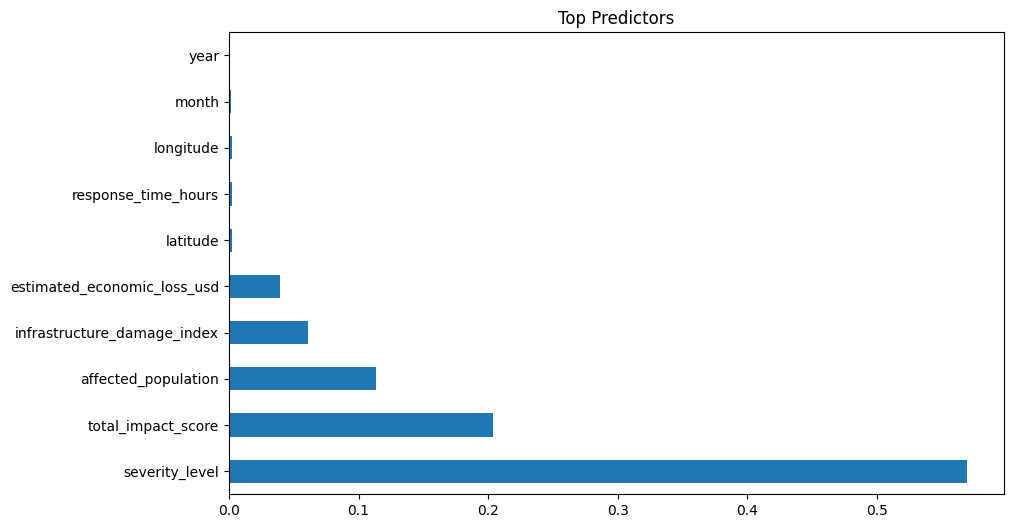

In [18]:
# DISASTER PREDICTION update as of March 12, 2026 @ 10:38am
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. DATA LOAD ---
RAW_GITHUB_URL = 'https://raw.githubusercontent.com/noodlejacknetwork/Disaster-Prediction-2025/refs/heads/main/unclean_dataset.csv'

try:
    df = pd.read_csv(RAW_GITHUB_URL, on_bad_lines='skip')
    print(f"✅ Success: Data streamed. Rows: {len(df)}")
except Exception as e:
    print(f"❌ Error: {e}")
    raise

# --- 2. CLEANING TEXT (covert them to 1 and 0) ---
df = df.replace({'Yes': 1, 'No': 0, 'Major': 1, 'Minor': 0})

# If severity_level is text (Low/Med/High)
severity_map = {'Low': 1, 'Medium': 2, 'High': 3}
if df['severity_level'].dtype == 'object':
    df['severity_level'] = df['severity_level'].map(severity_map).fillna(2)

# --- 3. PREPROCESSING ---
if 'event_id' in df.columns:
    df = df.drop(columns=['event_id'])

# Handle Dates
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df = df.drop(columns=['date'])

# Log Transform and One-Hot Encoding for remaining text (Location/Type)
df['affected_population'] = np.log1p(df['affected_population'])
df = pd.get_dummies(df, columns=['disaster_type', 'location'], drop_first=True)

# PCA for Total Impact Score
pca_features = ['severity_level', 'affected_population', 'infrastructure_damage_index']
x_pca = StandardScaler().fit_transform(df[pca_features])
pca = PCA(n_components=1)
df['total_impact_score'] = pca.fit_transform(x_pca)

# --- 4. MODEL TRAINING ---
y = df['is_major_disaster'].astype(int)
X = df.drop(columns=['is_major_disaster'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

model = RandomForestClassifier(n_estimators=260, max_depth=20, criterion='entropy', random_state=42)
model.fit(X_train, y_train)

# --- 5. RESULTS ---
y_pred = model.predict(X_test)
print("\n" + "="*40)
print(f" FINAL MODEL ACCURACY: {accuracy_score(y_test, y_pred):.4f}")
print("="*40)

# Visual: Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Visual: Feature Importance
plt.figure(figsize=(10, 6))
pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh')
plt.title("Top Predictors")
plt.show()